<div style="text-align:center; background-color:#1e293b; padding:20px; border-radius:10px;">
  <h1 style="font-family: 'Times New Roman', Times, serif; margin:0;">
    <b style="color:white;">Codroid</b>
    <span style="color:#38bdf8;"><b>Hub</b></span>
          <b style="color:white;">Pvt. Ltd.</b>

  </h1>
</div>

<div style="padding:35px; background-color:#1a1a1a; border-radius:15px; border: 3px solid #00ffcc; text-align:center;">

 <h1 style="color:#00ffcc;">AI Virtual Mouse</h1>

   <p style="color:#ffffff; font-size:18px;">
        Control your system cursor and clicks using real-time hand gestures.
    </p>

   <hr style="border: 0.5px solid #444;">

   <div style="text-align:left; color:#e0e0e0;">
        <ul>
            <li>Move cursor using index finger</li>
            <li>Pinch gestures for mouse clicks</li>
            <li>Smooth and responsive control</li>
        </ul>
    </div>

</div>

<div style="padding:35px; background-color:#1a1a1a; border-radius:15px; border: 3px solid #00ffcc; text-align:center;">

 <h1 style="color:#00ffcc; font-family:'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
        The Logic
    </h1>

 <p style="color:#ffffff; font-size:18px;">
        The system tracks finger positions and uses distance between them to control cursor movement and clicks.
    </p>

 <hr style="border: 0.5px solid #444;">

  <div style="text-align:left; color:#e0e0e0;">
        <ul>
            <li><b>Index Finger:</b> Controls cursor movement</li>
            <li><b>Coordinate Mapping:</b> Converts camera space → screen space</li>
            <li><b>Smoothening:</b> Reduces cursor jitter</li>
            <li><b>Thumb + Index:</b> Triggers Left Click</li>
            <li><b>Index + Middle:</b> Triggers Right Click</li>
            <li><b>Distance Check:</b> Uses threshold to detect gestures</li>
        </ul>
    </div>

</div>

<div style="padding:35px; background-color:#1a1a1a; border-radius:15px; border: 3px solid #00ffcc; text-align:center;">

 <h1 style="color:#00ffcc; font-family:'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
        Workflow
    </h1>

  <p style="color:#ffffff; font-size:18px;">
        Step-by-step flow of how the Virtual Mouse system operates.
    </p>

 <hr style="border: 0.5px solid #444;">

 <div style="text-align:left; color:#e0e0e0;">
        <ul>
            <li>Capture live video from webcam</li>
            <li>Detect hand landmarks using MediaPipe</li>
            <li>Extract key finger positions</li>
            <li>Map hand coordinates to screen size</li>
            <li>Apply smoothening for stable cursor movement</li>
            <li>Detect gestures using finger distance</li>
            <li>Perform mouse actions (move, left click, right click)</li>
        </ul>
    </div>

</div>

<div style="padding:5px; background-color:#1a1a1a; border-radius:15px; border: 3px solid #00ffcc; text-align:left;">
<div style=" background-color:#1a1a1a; padding:20px; border-radius:10px;">
  <h2 style="font-family: 'Times New Roman', Times, serif; margin:0;">
    <b style="color:#00ffcc;">Live Working :-</b>
  </h2>
</div>
</div>

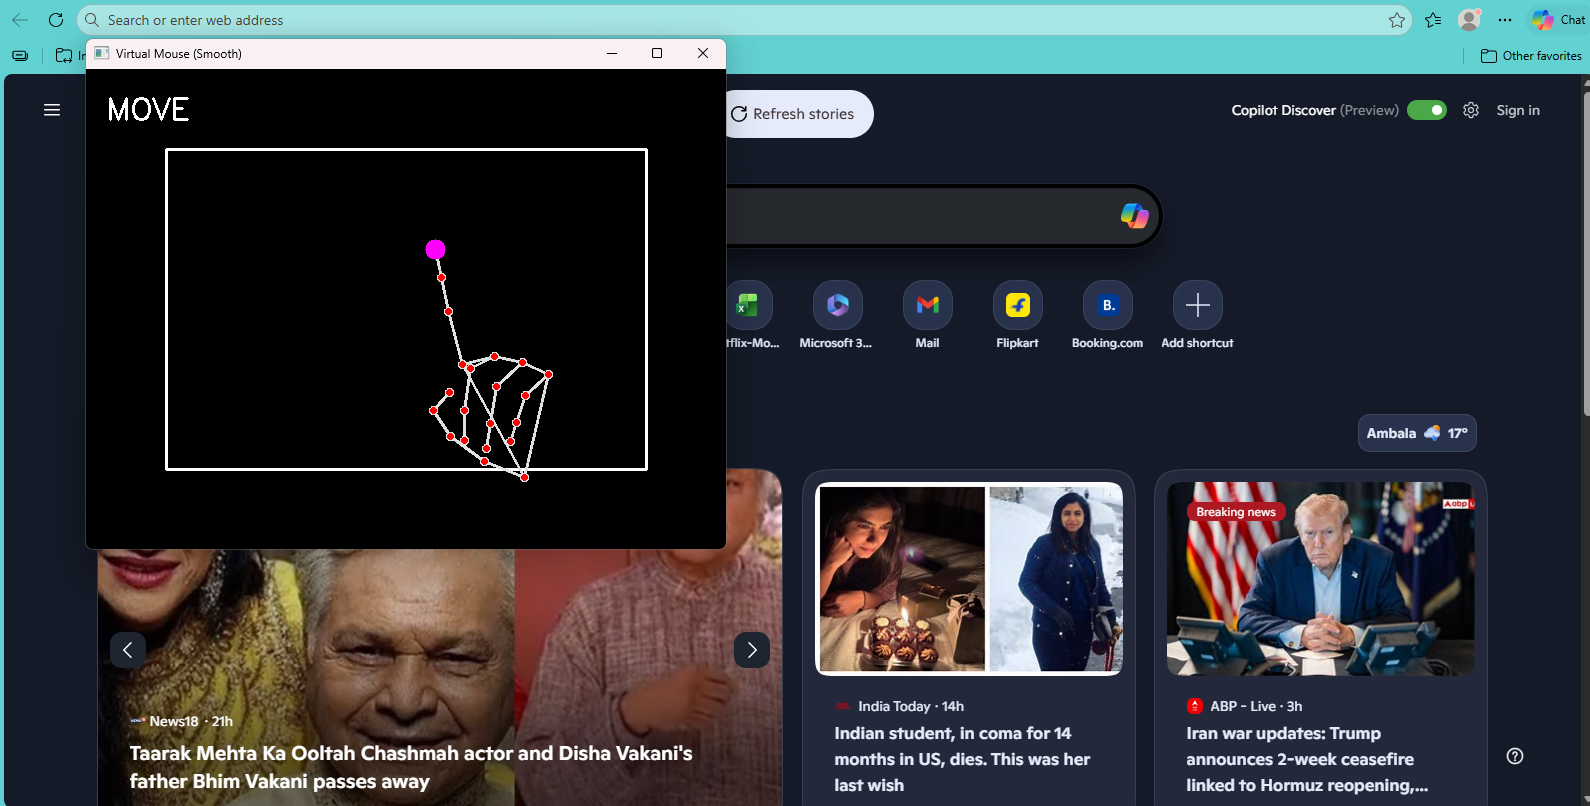

In [3]:
# for display the image using python
from IPython.display import Image, display
display(Image(filename='v_m.png'))



<div style="text-align:center; background:linear-gradient(135deg,#1e293b,#0f172a); padding:20px; border-radius:15px;">
  <img src="v_m.png" width="1000" 
       style="border:3px solid #38bdf8; border-radius:10px; padding:5px;">
</div>

In [1]:
# base libraries 

import cv2
import mediapipe as mp
import pyautogui
import numpy as np
import math
import time

<div style="padding:35px; background-color:#1a1a1a; border-radius:15px; border: 3px solid #00ffcc; text-align:left;">

  <h1 style="color:#00ffcc; font-family:'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
        Base Libraries Used
    </h1>

  <p style="color:#ffffff; font-size:18px;">
        Core libraries required to build the Virtual Mouse system.
    </p>

  <hr style="border: 0.5px solid #444;">

  <div style="text-align:left; color:#e0e0e0;">
        <ul>
            <li><b>OpenCV:</b> Handles video capture and image processing</li>
            <li><b>MediaPipe:</b> Performs real-time hand tracking</li>
            <li><b>PyAutoGUI:</b> Controls mouse movement and clicks</li>
            <li><b>NumPy:</b> Used for coordinate mapping and arrays</li>
            <li><b>Math:</b> Calculates distances between fingers</li>
            <li><b>Time:</b> Manages delays and timing between actions</li>
        </ul>
    </div>

</div>

<div style="padding:35px; background-color:#1a1a1a; border-radius:15px; border: 3px solid #00ffcc; text-align:left;">

<h1 style="color:#00ffcc; font-family:'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
        Libraries & Versions
    </h1>

 <p style="color:#ffffff; font-size:18px;">
        Versions of libraries used to build the Virtual Mouse system.
    </p>

 <hr style="border: 0.5px solid #444;">

<div style="text-align:left; color:#e0e0e0;">
        <ul>
            <li><b>OpenCV:</b> 4.x</li>
            <li><b>MediaPipe:</b> 0.10.x</li>
            <li><b>PyAutoGUI:</b> 0.9.x</li>
            <li><b>NumPy:</b> 1.x</li>
            <li><b>Math:</b> Built-in (Python Standard Library)</li>
            <li><b>Time:</b> Built-in (Python Standard Library)</li>
            
</ul>
</div>

</div>

In [ ]:
# Screen size
screen_w, screen_h = pyautogui.size()

<div style="padding:35px; background-color:#1a1a1a; border-radius:15px; border: 3px solid #00ffcc; text-align:center;">

  <h1 style="color:#00ffcc; font-family:'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
        Screen Size Detection
    </h1>

 <p style="color:#ffffff; font-size:18px;">
        Retrieves the system's screen resolution to map hand movement to cursor position.
    </p>

  <hr style="border: 0.5px solid #444;">

  <div style="text-align:left; color:#e0e0e0;">
        <ul>
            <li><b>pyautogui.size():</b> Gets screen width and height</li>
            <li><b>screen_w, screen_h:</b> Stores resolution values</li>
            <li><b>Purpose:</b> Maps camera coordinates to full screen movement</li>
        </ul>
    </div>

</div>

In [ ]:
# Camera
cam_w, cam_h = 640, 480
cap = cv2.VideoCapture(0)
cap.set(3, cam_w)
cap.set(4, cam_h)

<div style="padding:35px; background-color:#1a1a1a; border-radius:15px; border: 3px solid #00ffcc; text-align:center;">

   <h1 style="color:#00ffcc; font-family:'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
        Camera Setup
    </h1>

  <p style="color:#ffffff; font-size:18px;">
        Initializes the webcam and sets resolution for hand tracking.
    </p>

  <hr style="border: 0.5px solid #444;">

<div style="text-align:left; color:#e0e0e0;">
        <ul>
            <li><b>cam_w, cam_h:</b> Defines camera resolution (640x480)</li>
            <li><b>VideoCapture(0):</b> Starts default webcam</li>
            <li><b>cap.set(3, 640):</b> Sets frame width</li>
            <li><b>cap.set(4, 480):</b> Sets frame height</li>
        </ul>
    </div>

</div>

In [ ]:
# Mediapipe
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=1, min_detection_confidence=0.75)
mp_draw = mp.solutions.drawing_utils

<div style="padding:35px; background-color:#1a1a1a; border-radius:15px; border: 3px solid #00ffcc; text-align:center;">

 <h1 style="color:#00ffcc; font-family:'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
        MediaPipe Hand Tracking
    </h1>

 <p style="color:#ffffff; font-size:18px;">
        Initializes hand detection model and utilities for drawing landmarks.
    </p>

<hr style="border: 0.5px solid #444;">

<div style="text-align:left; color:#e0e0e0;">
        <ul>
            <li><b>mp.solutions.hands:</b> Loads hand tracking module</li>
            <li><b>max_num_hands=1:</b> Detects only one hand</li>
            <li><b>min_detection_confidence=0.75:</b> Improves detection accuracy</li>
            <li><b>drawing_utils:</b> Draws hand landmarks on screen</li>
        </ul>
    </div>

</div>

In [ ]:
# Smooth control
prev_x, prev_y = 0, 0
smoothening = 3   #  lower = less lag

# Click delay
click_delay = 0.3
last_click_time = 0

# Dead zone (ignore micro movement)
dead_zone = 5

# Frame margin
frame_margin = 80


<div style="padding:35px; background-color:#1a1a1a; border-radius:15px; border: 3px solid #00ffcc; text-align:center;">

  <h1 style="color:#00ffcc; font-family:'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
        Control Optimization
    </h1>

 <p style="color:#ffffff; font-size:18px;">
        Improves cursor stability, click accuracy, and overall user experience.
    </p>

 <hr style="border: 0.5px solid #444;">

   <div style="text-align:left; color:#e0e0e0;">
        <ul>
            <li><b>Smoothening:</b> Reduces cursor jitter using previous position</li>
            <li><b>prev_x, prev_y:</b> Stores last cursor position</li>
            <li><b>click_delay:</b> Prevents multiple rapid clicks</li>
            <li><b>last_click_time:</b> Tracks last click timestamp</li>
            <li><b>dead_zone:</b> Ignores small unwanted movements</li>
            <li><b>frame_margin:</b> Limits active tracking area for better control</li>
        </ul>
    </div>

</div>

In [ ]:
# Finger state helper
def fingers_up(hand_landmarks):
    tips = [8, 12, 16, 20]
    fingers = []

    # Index, Middle, Ring, Pinky
    for tip in tips:
        if hand_landmarks.landmark[tip].y < hand_landmarks.landmark[tip - 2].y:
            fingers.append(1)
        else:
            fingers.append(0)

    return fingers


<div style="padding:35px; background-color:#1a1a1a; border-radius:15px; border: 3px solid #00ffcc; text-align:center;">

 <h1 style="color:#00ffcc; font-family:'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
        Finger State Detection
    </h1>

 <p style="color:#ffffff; font-size:18px;">
        Identifies which fingers are raised using hand landmark positions.
    </p>

  <hr style="border: 0.5px solid #444;">

 <div style="text-align:left; color:#e0e0e0;">
        <ul>
            <li><b>tips:</b> Landmark indices for fingertips (Index → Pinky)</li>
            <li><b>Logic:</b> Tip above joint → Finger is UP (1)</li>
            <li><b>Comparison:</b> Uses vertical (y-axis) position</li>
            <li><b>Output:</b> Returns list like [1,0,1,0]</li>
        </ul>
    </div>

</div>

In [2]:
while True:
    success, frame = cap.read()
    if not success:
        continue

    frame = cv2.flip(frame, 1)
    img = np.zeros((cam_h, cam_w, 3), np.uint8)

    cv2.rectangle(img, (frame_margin, frame_margin),
                  (cam_w - frame_margin, cam_h - frame_margin),
                  (255, 255, 255), 2)

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = hands.process(rgb)

    if result.multi_hand_landmarks:
        for hand_landmarks in result.multi_hand_landmarks:

            mp_draw.draw_landmarks(img, hand_landmarks, mp_hands.HAND_CONNECTIONS)

            h, w, _ = frame.shape

            # Landmarks
            index_tip = hand_landmarks.landmark[8]
            thumb_tip = hand_landmarks.landmark[4]
            middle_tip = hand_landmarks.landmark[12]

            ix, iy = int(index_tip.x * w), int(index_tip.y * h)
            tx, ty = int(thumb_tip.x * w), int(thumb_tip.y * h)
            mx, my = int(middle_tip.x * w), int(middle_tip.y * h)

            fingers = fingers_up(hand_landmarks)

            # Distances
            thumb_index_dist = math.hypot(ix - tx, iy - ty)
            index_middle_dist = math.hypot(ix - mx, iy - my)

            current_time = time.time()

            #  MOVE CURSOR (ONLY index finger up)
            if fingers == [1, 0, 0, 0]:

                screen_x = np.interp(ix, (frame_margin, cam_w - frame_margin), (0, screen_w))
                screen_y = np.interp(iy, (frame_margin, cam_h - frame_margin), (0, screen_h))

                # Dead zone filter
                if abs(screen_x - prev_x) < dead_zone:
                    screen_x = prev_x
                if abs(screen_y - prev_y) < dead_zone:
                    screen_y = prev_y

                # Smooth movement
                curr_x = prev_x + (screen_x - prev_x) / smoothening
                curr_y = prev_y + (screen_y - prev_y) / smoothening

                pyautogui.moveTo(curr_x, curr_y)
                prev_x, prev_y = curr_x, curr_y

                cv2.putText(img, "MOVE", (20, 50),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

            #  FREEZE (all fingers down)
            elif fingers == [0, 0, 0, 0]:
                cv2.putText(img, "FREEZE", (20, 50),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (200, 200, 200), 2)

            #  LEFT CLICK
            if thumb_index_dist < 30:
                cv2.line(img, (ix, iy), (tx, ty), (0, 255, 0), 3)

                if current_time - last_click_time > click_delay:
                    pyautogui.click()
                    last_click_time = current_time

                cv2.putText(img, "LEFT CLICK", (20, 100),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

            #  RIGHT CLICK
            if index_middle_dist < 30:
                cv2.line(img, (ix, iy), (mx, my), (0, 0, 255), 3)

                if current_time - last_click_time > click_delay:
                    pyautogui.rightClick()
                    last_click_time = current_time

                cv2.putText(img, "RIGHT CLICK", (20, 150),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

            # Cursor UI
            cv2.circle(img, (ix, iy), 10, (255, 0, 255), -1)

    cv2.imshow("Virtual Mouse (Smooth)", img)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

<div style="padding:35px; background-color:#1a1a1a; border-radius:15px; border: 3px solid #00ffcc; text-align:center;">

 <h1 style="color:#00ffcc; font-family:'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
        Main Control Loop
    </h1>

  <p style="color:#ffffff; font-size:18px;">
        Processes hand gestures in real-time to control cursor movement and mouse actions.
    </p>

<hr style="border: 0.5px solid #444;">

 <div style="text-align:left; color:#e0e0e0;">
        <ul>
            <li><b>Frame Capture:</b> Reads and flips webcam feed</li>
            <li><b>Black UI + Frame Box:</b> Defines active control area</li>
            <li><b>Hand Detection:</b> Tracks landmarks using MediaPipe</li>
            <li><b>Finger State:</b> Determines gesture using helper function</li>
            <li><b>Cursor Move:</b> Index finger → Smooth mapped movement</li>
            <li><b>Dead Zone:</b> Filters small unwanted movements</li>
            <li><b>Freeze:</b> All fingers down → Stops cursor</li>
            <li><b>Left Click:</b> Thumb + Index pinch</li>
            <li><b>Right Click:</b> Index + Middle pinch</li>
            <li><b>Click Delay:</b> Prevents multiple rapid clicks</li>
            <li><b>UI Feedback:</b> Displays actions on screen</li>
            <li><b>Exit:</b> Press ESC to close application</li>
        </ul>
    </div>

</div>

<div style="text-align:center; background-color:#1e293b; padding:20px; border-radius:10px;">
  <h1 style="font-family: 'Times New Roman', Times, serif; margin:0;">
    <b style="color:white;">Thank</b>
    <span style="color:#38bdf8;"><b>You</b></span>

  </h1>
</div>